In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Notebook location recommendation:
# Battery_Analysis/notebooks/analyze_stage4_trials.ipynb
PROJECT_ROOT = Path("..")  # Battery_Analysis/
RUN_ROOT = PROJECT_ROOT / "new" / "stage4mix_39332946"

RUN_ROOT.exists(), RUN_ROOT


(True, WindowsPath('../new/stage4mix_39332946'))

In [2]:
def parse_task_trial(folder_name: str):
    m = re.match(r"task_(\d+)_trial_(\d+)$", folder_name)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def infer_mode_from_path(p: Path):
    # expects .../stage4mix_XXXX/{mode}/task_.../stage4_trials.csv
    parts = [x.lower() for x in p.parts]
    for m in ("real", "synth_free", "synth_locked"):
        if m in parts:
            return m
    return "unknown"


In [3]:
def load_all_stage4_trials(run_root: Path) -> pd.DataFrame:
    rows = []
    csv_paths = list(run_root.rglob("stage4_trials.csv"))
    print("Found stage4_trials.csv files:", len(csv_paths))

    for csv_path in csv_paths:
        mode = infer_mode_from_path(csv_path)
        run_folder = csv_path.parent  # task_XX_trial_YY
        task, trial = parse_task_trial(run_folder.name)

        # if structure differs, walk up to find task/trial
        if task is None:
            for p in run_folder.parents:
                task, trial = parse_task_trial(p.name)
                if task is not None:
                    break

        try:
            df = pd.read_csv(csv_path)
            df["mode"] = mode
            df["task"] = task
            df["run_trial"] = trial  # avoid name clash with df["trial"]
            df["run_folder"] = run_folder.name
            df["source_csv"] = str(csv_path)
            rows.append(df)
        except Exception as e:
            print("[warn] failed reading:", csv_path, "err:", repr(e))

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    return out

df = load_all_stage4_trials(RUN_ROOT)
df.shape, df.head()


Found stage4_trials.csv files: 149


((1634, 26),
    trial  x0trial  ok_run   pre_max  post_max       mse       wall_s  \
 0      0        2       1  1.394506  0.269165  0.007493  6096.561941   
 1      0       13       1  2.194498  0.266940  0.010737  7002.034699   
 2      0       11       1  1.979774  0.887007  0.023708  6551.490103   
 3      0       12       1  1.179338  0.887026  0.023710  6685.245139   
 4      0        4       0       inf       inf       inf  5360.882816   
 
                                                  err       xn0       xp0  ...  \
 0                                                NaN  0.208090  0.826861  ...   
 1                                                NaN  0.850539  0.890639  ...   
 2                                                NaN  0.699340  0.522819  ...   
 3                                                NaN  0.329218  0.487252  ...   
 4  ValueError('INTERNAL: CpuCallback error callin...  0.430418  0.075488  ...   
 
         sDp       sDe        gn           gp        

In [4]:
if len(df) == 0:
    raise RuntimeError("No stage4_trials.csv loaded. Check RUN_ROOT path.")

# Ensure required columns exist
required = {"ok_run", "mse", "post_max"}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing expected columns in stage4_trials.csv: {missing}")

# normalize types
df["ok_run"] = pd.to_numeric(df["ok_run"], errors="coerce").fillna(0).astype(int)
df["mse"] = pd.to_numeric(df["mse"], errors="coerce")
df["post_max"] = pd.to_numeric(df["post_max"], errors="coerce")

# optional: remove inf
df = df.replace([np.inf, -np.inf], np.nan)

print("Rows:", len(df))
print("Modes:", df["mode"].value_counts().to_dict())
print("Overall ok_run rate:", df["ok_run"].mean())


Rows: 1634
Modes: {'synth_free': 800, 'real': 784, 'synth_locked': 50}
Overall ok_run rate: 0.6144430844553244


In [5]:
run_keys = ["mode", "task", "run_trial", "run_folder", "source_csv"]

def per_run_stats(df_all: pd.DataFrame) -> pd.DataFrame:
    # successful trials only
    df_succ = df_all[df_all["ok_run"] == 1].copy()

    # per-run metrics
    grp_all = df_all.groupby(run_keys, dropna=False)
    grp_succ = df_succ.groupby(run_keys, dropna=False)

    out = grp_all.agg(
        total_trials=("ok_run", "size"),
        succ_trials=("ok_run", "sum"),
        succ_rate=("ok_run", "mean"),
    ).reset_index()

    # best-of-run (min mse among successful trials)
    best = grp_succ["mse"].min().rename("best_mse").reset_index()

    # median-of-run (median mse among successful trials)
    med = grp_succ["mse"].median().rename("median_mse").reset_index()

    # join
    out = out.merge(best, on=run_keys, how="left").merge(med, on=run_keys, how="left")
    return out

df_run = per_run_stats(df)
df_run.shape, df_run.head()


((149, 10),
    mode  task  run_trial      run_folder  \
 0  real     0          0  task_0_trial_0   
 1  real     1          1  task_1_trial_1   
 2  real     2          2  task_2_trial_2   
 3  real     3          3  task_3_trial_3   
 4  real     4          4  task_4_trial_4   
 
                                           source_csv  total_trials  \
 0  ..\new\stage4mix_39332946\real\task_0_trial_0\...            16   
 1  ..\new\stage4mix_39332946\real\task_1_trial_1\...            16   
 2  ..\new\stage4mix_39332946\real\task_2_trial_2\...            16   
 3  ..\new\stage4mix_39332946\real\task_3_trial_3\...            16   
 4  ..\new\stage4mix_39332946\real\task_4_trial_4\...            16   
 
    succ_trials  succ_rate  best_mse  median_mse  
 0            4     0.2500  0.007493    0.017223  
 1            7     0.4375  0.001495    0.010737  
 2           13     0.8125  0.000979    0.010617  
 3            8     0.5000  0.007810    0.010737  
 4            6     0.3750  0.001

In [6]:
mode_summary = df_run.groupby("mode").agg(
    runs=("run_folder", "nunique"),
    avg_succ_rate=("succ_rate", "mean"),
    median_succ_rate=("succ_rate", "median"),
    avg_best_mse=("best_mse", "mean"),
    median_best_mse=("best_mse", "median"),
    avg_median_mse=("median_mse", "mean"),
    median_median_mse=("median_mse", "median"),
).sort_values("median_best_mse", ascending=True)

mode_summary


,runs,avg_succ_rate,median_succ_rate,avg_best_mse,median_best_mse,avg_median_mse,median_median_mse
mode,,,,,,,
synth_locked,50,1.000000,1.000,5.241222e-09,1.867248e-09,5.241222e-09,1.867248e-09
synth_free,50,0.622500,0.625,7.944485e-09,6.962871e-09,3.177013e-08,2.959304e-08
real,49,0.581633,0.625,2.428593e-03,1.013147e-03,1.078355e-02,1.073630e-02


In [7]:
df_run_sorted = df_run.sort_values(["best_mse", "median_mse"], ascending=True)
df_run_sorted.head(10)


,mode,task,run_trial,run_folder,source_csv,total_trials,succ_trials,succ_rate,best_mse,median_mse
81,synth_free,132,32,task_132_trial_32,..\new\stage4mix_39332946\synth_free\task_132_...,16,12,0.75,5.814315e-10,2.627935e-08
127,synth_locked,78,28,task_78_trial_28,..\new\stage4mix_39332946\synth_locked\task_78...,1,1,1.00,9.674063e-10,9.674063e-10
136,synth_locked,87,37,task_87_trial_37,..\new\stage4mix_39332946\synth_locked\task_87...,1,1,1.00,9.763769e-10,9.763769e-10
116,synth_locked,67,17,task_67_trial_17,..\new\stage4mix_39332946\synth_locked\task_67...,1,1,1.00,1.019151e-09,1.019151e-09
141,synth_locked,92,42,task_92_trial_42,..\new\stage4mix_39332946\synth_locked\task_92...,1,1,1.00,1.021305e-09,1.021305e-09
140,synth_locked,91,41,task_91_trial_41,..\new\stage4mix_39332946\synth_locked\task_91...,1,1,1.00,1.025032e-09,1.025032e-09
134,synth_locked,85,35,task_85_trial_35,..\new\stage4mix_39332946\synth_locked\task_85...,1,1,1.00,1.070313e-09,1.070313e-09
137,synth_locked,88,38,task_88_trial_38,..\new\stage4mix_39332946\synth_locked\task_88...,1,1,1.00,1.106206e-09,1.106206e-09
143,synth_locked,94,44,task_94_trial_44,..\new\stage4mix_39332946\synth_locked\task_94...,1,1,1.00,1.117570e-09,1.117570e-09
120,synth_locked,71,21,task_71_trial_21,..\new\stage4mix_39332946\synth_locked\task_71...,1,1,1.00,1.122901e-09,1.122901e-09


In [8]:
best = df_run_sorted.iloc[0]
print("=== GLOBAL BEST RUN ===")
print(best[["mode","task","run_trial","succ_trials","total_trials","succ_rate","best_mse","median_mse"]].to_dict())
print("source:", best["source_csv"])


=== GLOBAL BEST RUN ===
{'mode': 'synth_free', 'task': 132, 'run_trial': 32, 'succ_trials': 12, 'total_trials': 16, 'succ_rate': 0.75, 'best_mse': 5.814315372223537e-10, 'median_mse': 2.6279345280373372e-08}
source: ..\new\stage4mix_39332946\synth_free\task_132_trial_32\stage4_trials.csv


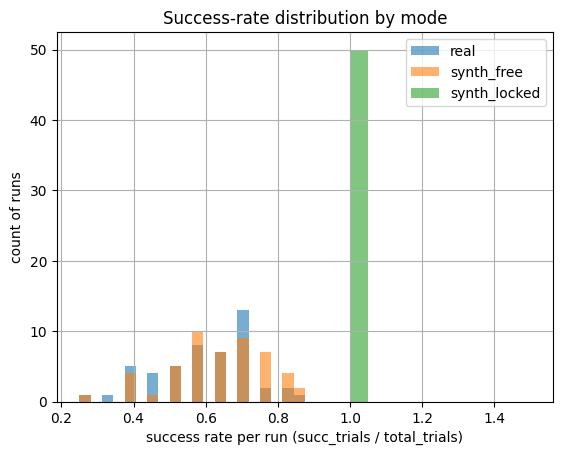

In [9]:
plt.figure()
for mode, g in df_run.groupby("mode"):
    plt.hist(g["succ_rate"].dropna().values, bins=20, alpha=0.6, label=mode)
plt.xlabel("success rate per run (succ_trials / total_trials)")
plt.ylabel("count of runs")
plt.title("Success-rate distribution by mode")
plt.grid(True)
plt.legend()
plt.show()


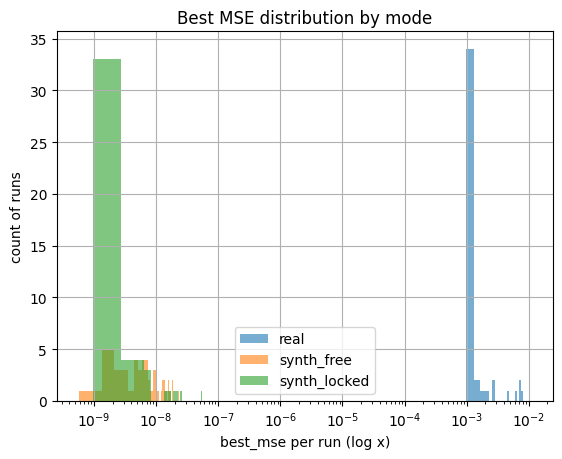

In [10]:
plt.figure()
for mode, g in df_run.groupby("mode"):
    x = g["best_mse"].dropna().values
    plt.hist(x, bins=30, alpha=0.6, label=mode)
plt.xscale("log")
plt.xlabel("best_mse per run (log x)")
plt.ylabel("count of runs")
plt.title("Best MSE distribution by mode")
plt.grid(True)
plt.legend()
plt.show()


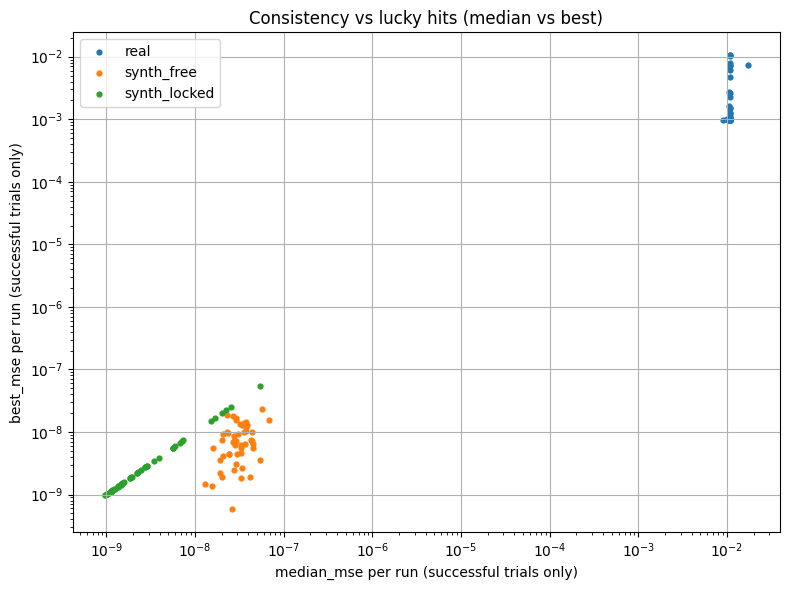

In [11]:
plt.figure(figsize=(8,6))
for mode, g in df_run.groupby("mode"):
    gg = g.dropna(subset=["best_mse", "median_mse"])
    plt.scatter(gg["median_mse"], gg["best_mse"], s=12, label=mode)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("median_mse per run (successful trials only)")
plt.ylabel("best_mse per run (successful trials only)")
plt.title("Consistency vs lucky hits (median vs best)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
